In [1]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import numpy as np
import pandas as pd
import xarray as xr
import torch
from pathlib import Path
import itertools

from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 600, "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib.models import DJModel
from lib.computation.statistics import cluster_correction
from lib.datasets import load_n_subjects, load_target_var, load_dataset
from lib.analyses.loaders import load_significant_times
from lib.analyses._plots import _plot_generalization, _plot_eigenspectrum
from bonner.caching import BONNER_CACHING_HOME
from bonner.computation.decomposition import PCA
from bonner.computation.metrics import covariance, pearson_r
from lib.computation.statistics import compute_p
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.datasets.hebart2022_things_behavior import sort_embeddings
from bonner.datasets.gifford2022_things_eeg_2 import load_metadata

# Import helper functions for memory-efficient loading
from lib._notebook_helpers import (
    get_scorer_kwargs,
    load_decoding_data_streaming,
    add_time_markers,
    plot_significance_bar,
)

In [2]:
# Common configuration
n_permutations = 1000
model_uid = "openclip_rn50_yfcc15m"

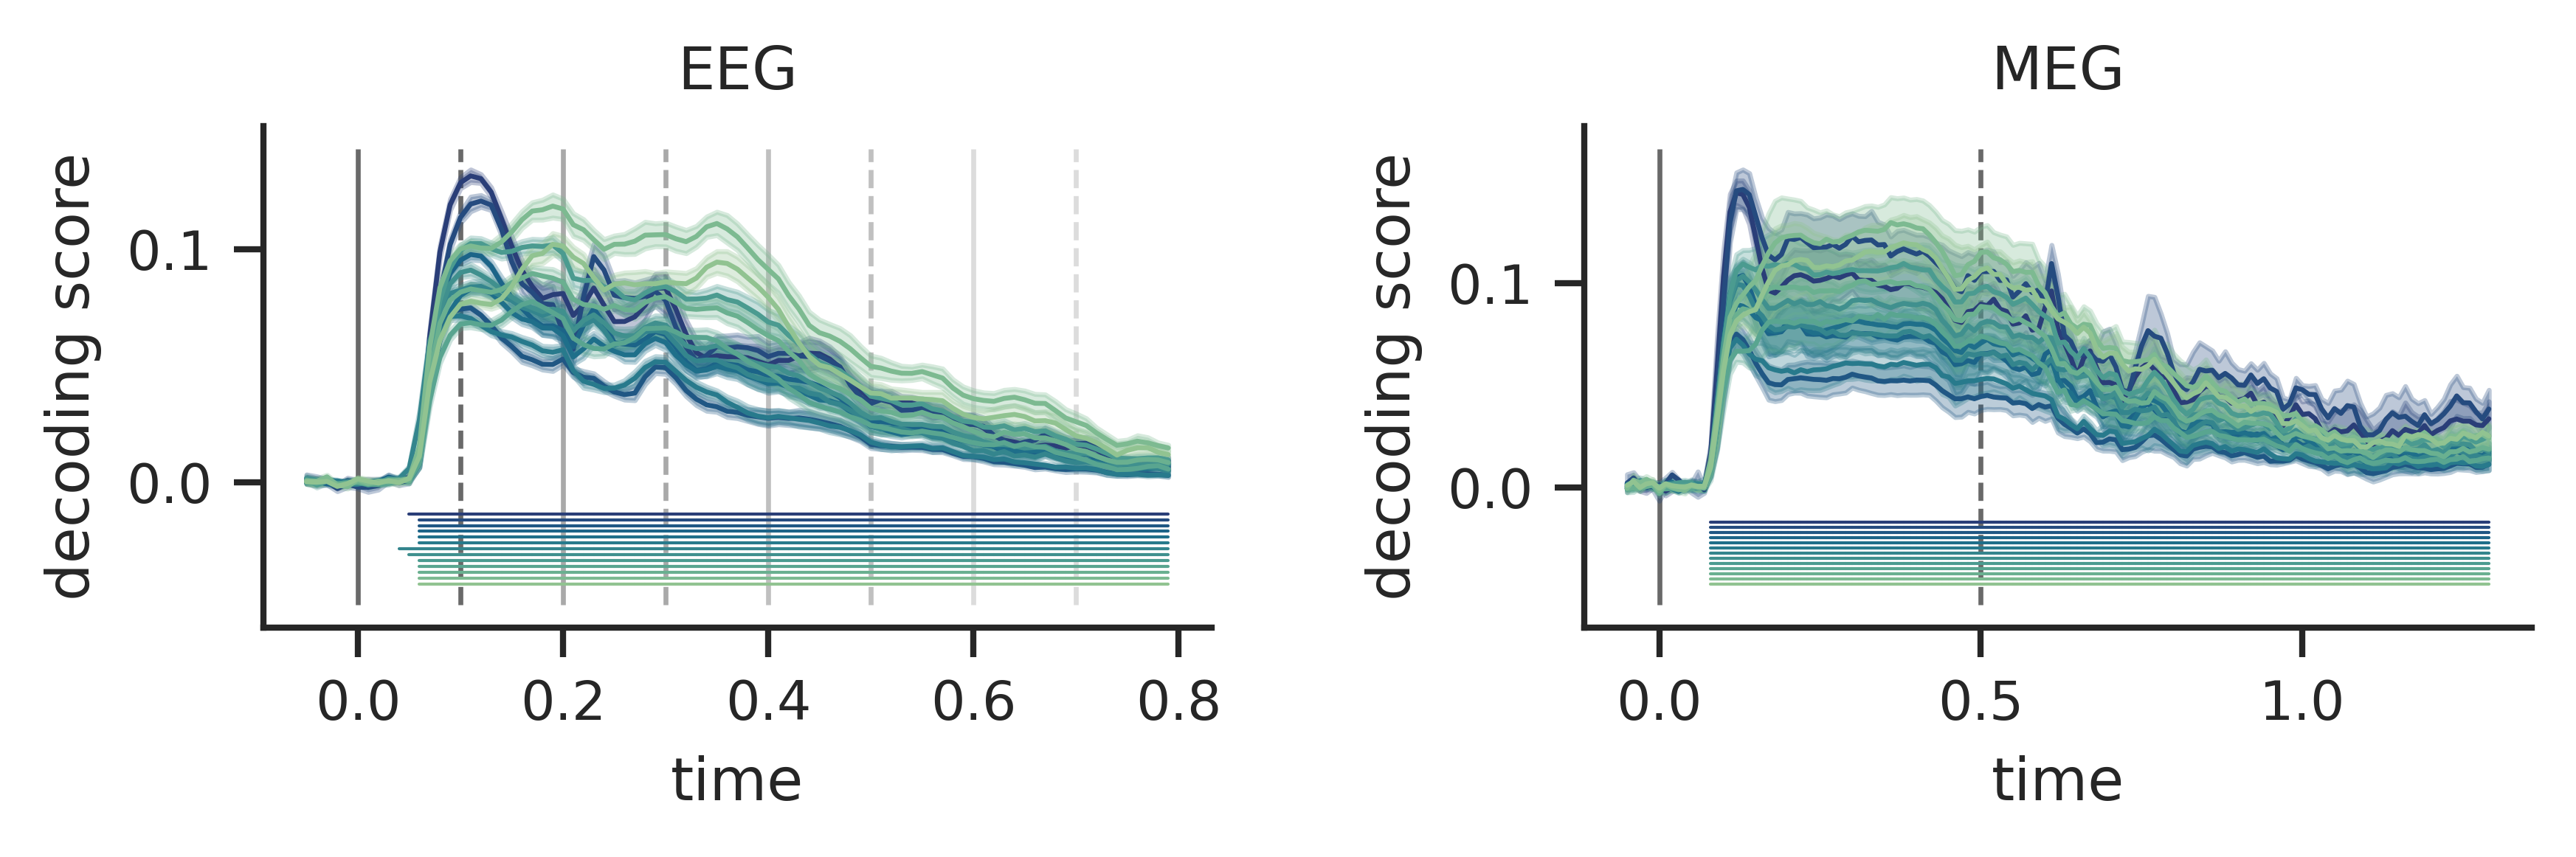

In [3]:
plt.close()
width_mm = 180
width_inches = width_mm / 25.4 -1
height_inches = (width_inches + 1) / 3.5
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(width_inches, height_inches),)

dataset = "things_eeg_2"
subjects = "all"
list_dim = "time"
folds = False
decoding_str = ".subset=False.pca=False"
load_dataset_kwargs = "default"

model_name = "linear"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)

subpath = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_full_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto"

########## EEG decoding results ##########
ax = axs[0]
ax.set_title("EEG")

# Load decoding data using streaming helper (13-node model)
xdf, sig_times = load_decoding_data_streaming(
    subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds, has_node=True
)

# Plot
sns.lineplot(data=xdf, x="time", y="score", ax=ax, palette=sns.color_palette("crest_r", n_colors=13), hue="node", errorbar=None, linewidth=.8)

for i, node_name in enumerate(xdf["node"].unique()):
    node_data = xdf[xdf["node"] == node_name]
    color = sns.color_palette("crest_r", n_colors=13)[i]
    score = node_data.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
    ax.fill_between(node_data.time.unique(), score-err, score+err, color=color, alpha=0.3)

ax.legend().remove()
ax.set(ylabel="decoding score")

# Plot significance bars
times = xdf.time.unique()
ypos = ax.get_ylim()[0]
for i, node in enumerate(xdf.node.unique()):
    plot_significance_bar(ax, sig_times[node], times, ypos-.0025-.0025*i, 
                         sns.color_palette("crest_r", n_colors=13)[i], linewidth=.5)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)

########## MEG decoding results ##########
dataset = "things_meg"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"

model_name = "linear"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)

subpath = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_full_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto"

ax = axs[1]
ax.set_title("MEG")

# Load decoding data using streaming helper
xdf, sig_times = load_decoding_data_streaming(
    subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds, has_node=True
)

# Plot
sns.lineplot(data=xdf, x="time", y="score", ax=ax, palette=sns.color_palette("crest_r", n_colors=13), hue="node", errorbar=None, linewidth=.8)

for i, node_name in enumerate(xdf["node"].unique()):
    node_data = xdf[xdf["node"] == node_name]
    color = sns.color_palette("crest_r", n_colors=13)[i]
    score = node_data.groupby(["time", "subject"]).score.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).score.mean().groupby("time").sem().values
    ax.fill_between(node_data.time.unique(), score-err, score+err, color=color, alpha=0.3)

ax.legend().remove()
ax.set(ylabel="decoding score")

# Plot significance bars
times = xdf.time.unique()
ypos = ax.get_ylim()[0]
for i, node in enumerate(xdf.node.unique()):
    plot_significance_bar(ax, sig_times[node], times, ypos-.0025-.0025*i,
                         sns.color_palette("crest_r", n_colors=13)[i], linewidth=.5)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)
    
plt.tight_layout()
sns.despine()

In [4]:
import torch
import torchvision
import numpy as np
import cv2
import xarray as xr

import json
import urllib
from collections import Counter
from glob import glob

from bonner.datasets.gifford2022_things_eeg_2._data import run_preprocessing, load_metadata, load_stimuli, load_events_list, StimulusSet

from lib.datasets import load_stimulus_set, load_dataloader
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.computation.regressions import load_regression
from lib.computation.scorers import ModelScorer
from lib.models import DJModel

from deepjuice import *
from deepjuice.extraction import FeatureExtractor
from deepjuice.model_zoo.options import get_deepjuice_model
from deepjuice.systemops.devices import cuda_device_report

In [5]:
dataset = "things_eeg_2_test"
dataloader_kwargs = {"batch_size": 32}
model_uid = 'openclip_rn50_yfcc15m'
model = DJModel(model_uid, nodes="Identity", node_subset=False)
feature_extractor = model(dataset, dataloader_kwargs=dataloader_kwargs, return_extractor=True)

INFO:root:Loaded RN50 model config.


INFO:root:Loading pretrained RN50 weights (yfcc15m).


Extracting sample maps with torchinfo:
  (Moving tensors from CUDA:0 to CPU)


In [6]:
dataloader = get_data_loader([f"{os.getenv("PROJECT_HOME")}/src/lib/models/example_stimuli/bnv.jpg" for i in range(3)], model.preprocess)
md = get_feature_map_metadata(model.model, dataloader, input_dim=0)
smd = md[md.output_uid.isin(feature_extractor.get_keep())].reset_index(drop=True)
smd

Parsing Info:   0%|          | 0/208 [00:00<?, ?it/s]

,output_uid,torchinfo_id,class_name,nest_level,nest_index,nest_depth,output_index,output_depth,module_index,module_name,...,parenting_names,input_shape,output_shape,output_bytes,output_dtype,features_total,params_total,params_trainable,kernel_size,is_recursive
0,Identity-3-7,Identity-3-7,Identity,3,7,0.042683,17,0.092391,19,avgpool,...,[],None,"[64, 56, 56]",802816,None,200704,0,0,None,False
1,Identity-3-18,Identity-3-18,Identity,3,18,0.109756,30,0.163043,34,avgpool,...,[1],None,"[64, 56, 56]",802816,None,200704,0,0,None,False
2,Identity-3-28,Identity-3-28,Identity,3,28,0.170732,40,0.217391,45,avgpool,...,[2],None,"[64, 56, 56]",802816,None,200704,0,0,None,False
3,Identity-3-49,Identity-3-49,Identity,3,49,0.298780,63,0.342391,72,avgpool,...,"[1, layer2]",None,"[128, 28, 28]",401408,None,100352,0,0,None,False
4,Identity-3-59,Identity-3-59,Identity,3,59,0.359756,73,0.396739,83,avgpool,...,"[2, layer2]",None,"[128, 28, 28]",401408,None,100352,0,0,None,False
5,Identity-3-69,Identity-3-69,Identity,3,69,0.420732,83,0.451087,94,avgpool,...,"[3, layer2]",None,"[128, 28, 28]",401408,None,100352,0,0,None,False
6,Identity-3-90,Identity-3-90,Identity,3,90,0.548780,106,0.576087,121,avgpool,...,"[1, layer3]",None,"[256, 14, 14]",200704,None,50176,0,0,None,False
7,Identity-3-100,Identity-3-100,Identity,3,100,0.609756,116,0.630435,132,avgpool,...,"[2, layer3]",None,"[256, 14, 14]",200704,None,50176,0,0,None,False
8,Identity-3-110,Identity-3-110,Identity,3,110,0.670732,126,0.684783,143,avgpool,...,"[3, layer3]",None,"[256, 14, 14]",200704,None,50176,0,0,None,False
9,Identity-3-120,Identity-3-120,Identity,3,120,0.731707,136,0.739130,154,avgpool,...,"[4, layer3]",None,"[256, 14, 14]",200704,None,50176,0,0,None,False


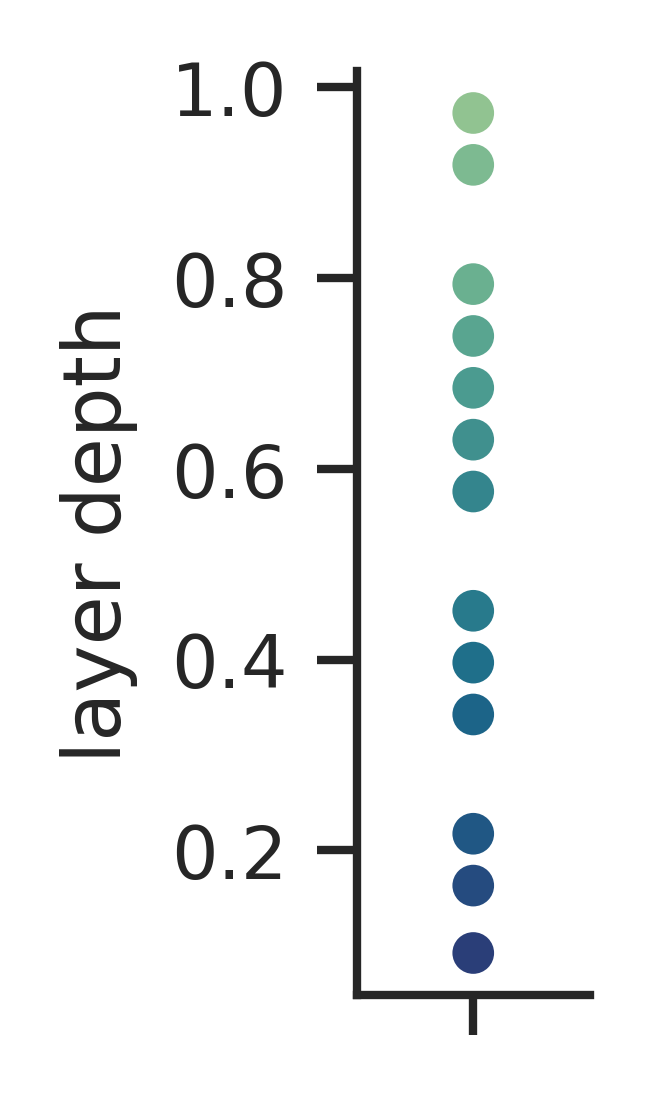

In [7]:
plt.close()
fig, ax = plt.subplots(figsize=(.5, 2))
sns.swarmplot(data=smd, y='output_depth', ax=ax, hue='output_depth', 
              palette=sns.color_palette("crest_r", n_colors=13), legend=False)
ax.set(ylabel="layer depth")
sns.despine()